# B_S3.7 — Z-Score Distribution Analysis

Descriptive analysis of per-metric Z-scores from the permutation test (B_S3).

Z-score = (obs − median_null) / IQR_null — measures how far a case's observed metric deviates from its permutation null, in robust standardized units.

| Section | Question |
|---------|----------|
| §1 | Setup and data loading |
| §2 | Null calibration: do null Z-scores center at 0 with IQR ≈ 1? |
| §3 | Summary statistics table: mean, median, Q95 by category × metric |
| §4 | Distribution plots: null vs signal Z-score histograms for top metrics |
| §5 | Separation quality: Cohen's d and AUC per metric |
| §6 | Z-score heatmap: mean Z by metric × category |
| §7 | Z-score by SNR: how Z grows with signal strength |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

S1_DIR = Path('output/S1')
S3_DIR = Path('output/S3')
OUT_DIR = Path('output/S3.7')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load permutation results ──
df = pd.read_parquet(S3_DIR / 'permutation_all.parquet')
Z_COLS = sorted([c for c in df.columns if c.startswith('z_')])

# ── Merge metadata ──
cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_null['case_id'] = cases_null['case_id'] + cases_main['case_id'].max()

meta_cols = ['case_id', 'family_id', 'snr', 'spread_pattern', 'x_distribution']
cases_all = pd.concat([cases_main[meta_cols], cases_null[meta_cols]], ignore_index=True)
df = df.merge(cases_all, on='case_id', how='left')

# ── Assign categories ──
is_null = df['family_id'] == 'Null'
is_const = df['spread_pattern'] == 'constant'
df['category'] = 'mean+variance'
df.loc[is_null & is_const, 'category'] = 'true_null'
df.loc[~is_null & is_const, 'category'] = 'mean_only'
df.loc[is_null & ~is_const, 'category'] = 'variance_only'

CAT_ORDER = ['true_null', 'mean_only', 'variance_only', 'mean+variance']
CAT_COLORS = {
    'true_null': '#999999',
    'mean_only': '#3b82f6',
    'variance_only': '#f59e0b',
    'mean+variance': '#10b981',
}
CAT_LABELS = {
    'true_null': 'Null (no relationship)',
    'mean_only': 'Mean-only',
    'variance_only': 'Variance-only',
    'mean+variance': 'Mean + Variance',
}

# ── Metric display names and groups ──
def metric_display(col):
    name = col.replace('z_', '')
    return {
        'abs_pearson_r': '|pearson|', 'abs_spearman_rho': '|spearman|',
        'abs_covariance': '|covariance|', 'mic_minus_r2': 'MIC−r²',
    }.get(name, name)

METRIC_DISPLAY = {c: metric_display(c) for c in Z_COLS}

METRIC_GROUPS = {}
for c in Z_COLS:
    name = c.replace('z_', '')
    if name in ('pearson', 'spearman', 'abs_pearson_r', 'abs_spearman_rho', 'abs_covariance'):
        METRIC_GROUPS[c] = 'correlation'
    elif 'dcor' in name or 'dcov' in name:
        METRIC_GROUPS[c] = 'distance'
    elif 'ep_' in name or 'pf_' in name or 'seg_' in name:
        METRIC_GROUPS[c] = 'slope'
    elif 'bin_' in name or name == 'eta2':
        METRIC_GROUPS[c] = 'bin'
    elif 'dist_' in name:
        METRIC_GROUPS[c] = 'distribution'
    elif name in ('mic', 'mas', 'mev', 'mcn', 'mic_minus_r2'):
        METRIC_GROUPS[c] = 'mine'
    elif name == 'lowess_r2':
        METRIC_GROUPS[c] = 'nonlinear'
    else:
        METRIC_GROUPS[c] = 'other'

GROUP_COLORS = {
    'correlation': '#e41a1c', 'distance': '#377eb8', 'slope': '#4daf4a',
    'bin': '#ff7f00', 'distribution': '#984ea3', 'mine': '#a65628',
    'nonlinear': '#f781bf', 'other': '#999999',
}

print(f'Loaded: {len(df):,} cases × {len(Z_COLS)} Z-score metrics')
print(f'\nCategories:')
for cat in CAT_ORDER:
    print(f'  {cat:18s}: {(df["category"] == cat).sum():,}')
print(f'\nSNR levels: {sorted(df["snr"].dropna().unique())}')

Loaded: 17,008 cases × 45 Z-score metrics

Categories:
  true_null         : 4,032
  mean_only         : 5,000
  variance_only     : 2,976
  mean+variance     : 5,000

SNR levels: [0.1, 0.3, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0, inf]


## §2 Null Calibration Check

If the permutation test is well-calibrated, Z-scores for true_null cases should have:
- Median ≈ 0 (centered)
- IQR ≈ 1 (unit spread)

Deviations indicate the metric's null distribution is biased or has unusual shape.

In [2]:
null_df = df[df['category'] == 'true_null']

calib_rows = []
for zc in Z_COLS:
    z = null_df[zc].dropna()
    if len(z) == 0:
        continue
    q25, q50, q75 = np.nanpercentile(z, [25, 50, 75])
    calib_rows.append({
        'metric': METRIC_DISPLAY[zc],
        'group': METRIC_GROUPS[zc],
        'n': len(z),
        'mean': z.mean(),
        'median': q50,
        'IQR': q75 - q25,
        'std': z.std(),
        'Q5': np.nanpercentile(z, 5),
        'Q95': np.nanpercentile(z, 95),
        'skew': float(sp_stats.skew(z, nan_policy='omit')),
    })

calib = pd.DataFrame(calib_rows)
calib['|median|'] = calib['median'].abs()
calib = calib.sort_values('|median|', ascending=False)

print('Null Z-score calibration (sorted by |median| deviation from 0):')
print(calib[['metric', 'group', 'n', 'mean', 'median', 'IQR', 'std', 'Q5', 'Q95', 'skew']]
      .to_string(index=False, float_format='{:.3f}'.format))

calib.to_csv(OUT_DIR / 'null_calibration.csv', index=False, float_format='%.4f')

Null Z-score calibration (sorted by |median| deviation from 0):
            metric        group    n   mean  median   IQR   std     Q5   Q95   skew
    abs_raw_pf_mid        slope 4032  0.172   0.042 1.039 0.760 -0.768 1.595  0.996
    abs_std_pf_mid        slope 4032  0.172   0.042 1.039 0.760 -0.768 1.595  0.996
   abs_raw_ep_late        slope 4032  0.238   0.036 1.038 0.961 -0.707 1.761  6.648
   abs_std_ep_late        slope 4032  0.238   0.036 1.038 0.961 -0.707 1.761  6.648
     ew_bin_bw_mid          bin 4032  0.029   0.028 1.026 0.803 -1.215 1.323  0.278
  raw_seg_strength        slope 4032  0.134   0.027 1.032 0.832 -0.984 1.613  1.312
  std_seg_strength        slope 4032  0.134   0.027 1.032 0.832 -0.984 1.613  1.312
   ec_bin_bw_early          bin 4032 -0.002  -0.021 1.059 0.780 -1.281 1.290  0.060
    ec_bin_bw_late          bin 4032 -0.006  -0.020 1.024 0.786 -1.254 1.279  0.029
       ew_bin_eta2          bin 4032  0.132  -0.019 1.035 0.828 -0.955 1.668  1.035
        |spe

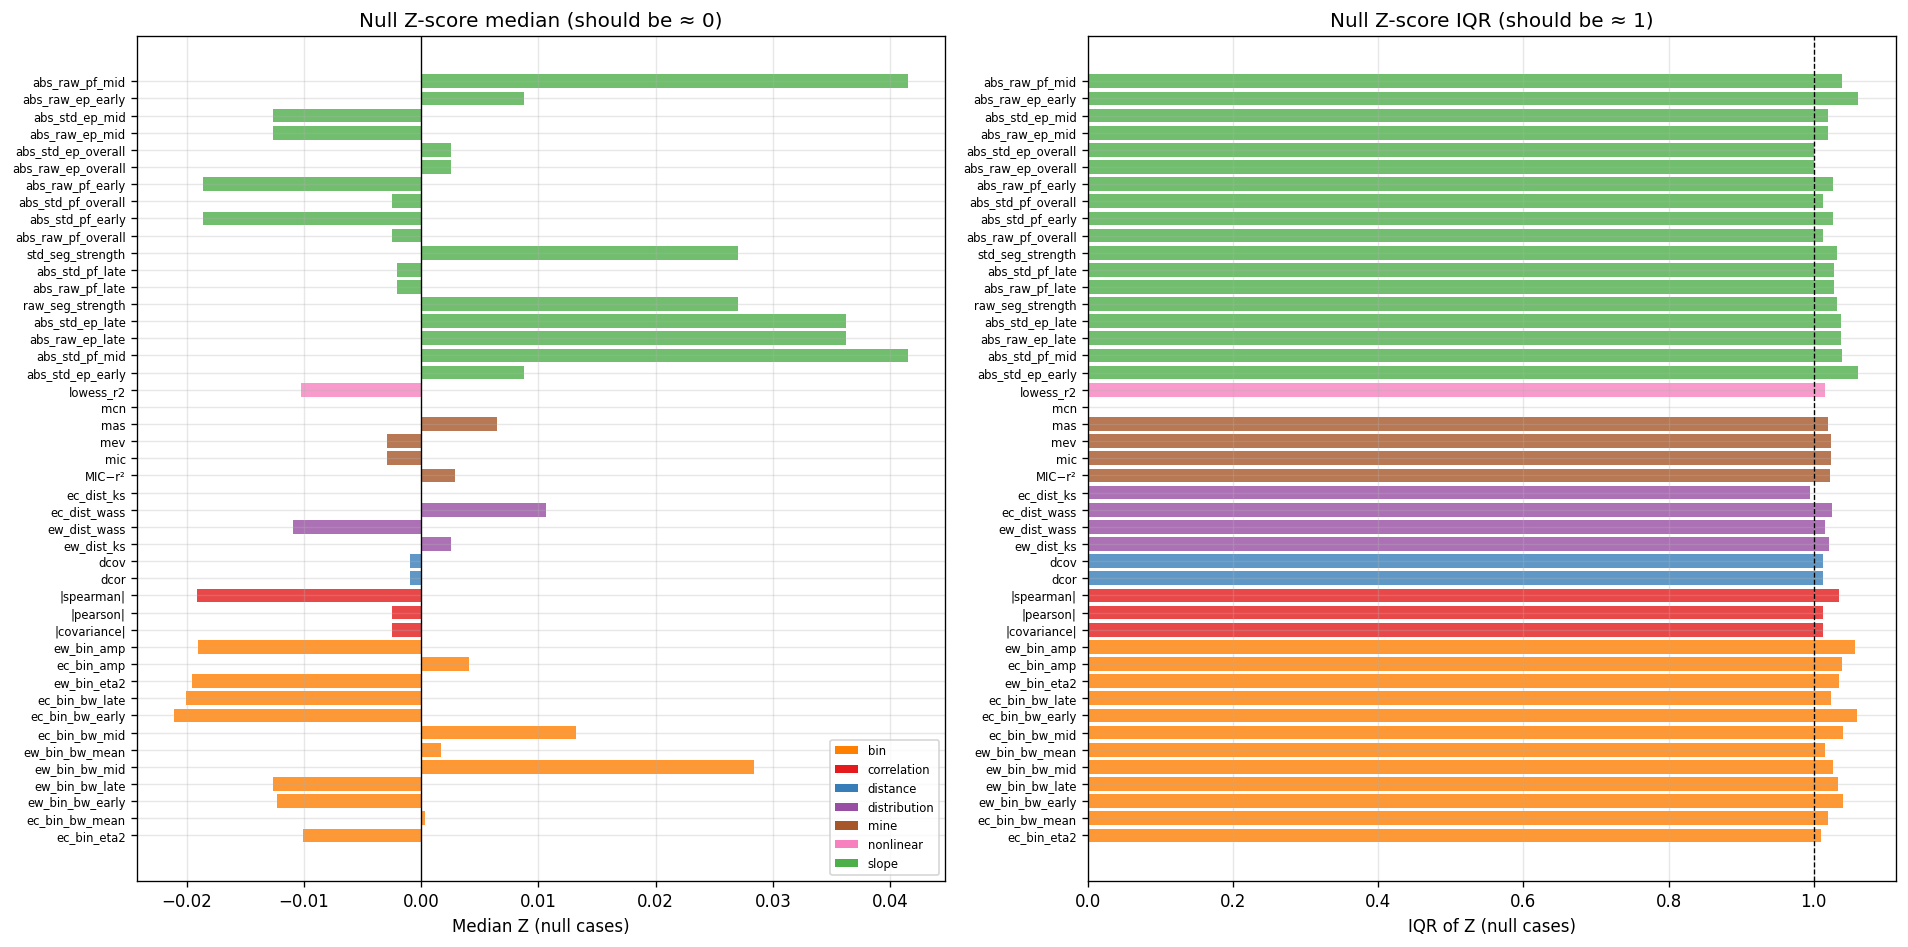

In [3]:
# Visualize null calibration: median and IQR for each metric
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

calib_plot = calib.sort_values('group')
colors = [GROUP_COLORS.get(g, '#999') for g in calib_plot['group']]

ax = axes[0]
ax.barh(range(len(calib_plot)), calib_plot['median'], color=colors, alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(range(len(calib_plot)))
ax.set_yticklabels(calib_plot['metric'], fontsize=7)
ax.set_xlabel('Median Z (null cases)')
ax.set_title('Null Z-score median (should be ≈ 0)')

ax = axes[1]
ax.barh(range(len(calib_plot)), calib_plot['IQR'], color=colors, alpha=0.8)
ax.axvline(1, color='black', lw=0.8, ls='--')
ax.set_yticks(range(len(calib_plot)))
ax.set_yticklabels(calib_plot['metric'], fontsize=7)
ax.set_xlabel('IQR of Z (null cases)')
ax.set_title('Null Z-score IQR (should be ≈ 1)')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=GROUP_COLORS[g], label=g) for g in sorted(GROUP_COLORS) if g in calib_plot['group'].values]
axes[0].legend(handles=legend_elements, fontsize=7, loc='lower right')

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig1_null_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

## §3 Summary Statistics by Category × Metric

For each metric, compare Z-score distributions across the four categories. Signal categories should have higher Z than null.

In [4]:
summary_rows = []
for zc in Z_COLS:
    for cat in CAT_ORDER:
        z = df.loc[df['category'] == cat, zc].dropna()
        if len(z) == 0:
            continue
        summary_rows.append({
            'metric': METRIC_DISPLAY[zc],
            'z_col': zc,
            'group': METRIC_GROUPS[zc],
            'category': cat,
            'n': len(z),
            'mean': z.mean(),
            'median': z.median(),
            'std': z.std(),
            'Q25': np.nanpercentile(z, 25),
            'Q75': np.nanpercentile(z, 75),
            'Q95': np.nanpercentile(z, 95),
        })

summary = pd.DataFrame(summary_rows)

# Use MEDIAN instead of mean for the pivot (robust to extreme outliers like lowess_r2)
pivot_med = summary.pivot_table(index='metric', columns='category', values='median')
pivot_med = pivot_med[CAT_ORDER]
pivot_med['signal_avg'] = pivot_med[['mean_only', 'variance_only', 'mean+variance']].mean(axis=1)
pivot_med['gap'] = pivot_med['signal_avg'] - pivot_med['true_null']
pivot_med = pivot_med.sort_values('gap', ascending=False)

print('Median Z-score by category (sorted by signal−null gap):')
print(pivot_med[CAT_ORDER + ['gap']].to_string(float_format='{:.2f}'.format))

# Flag metrics with extreme outliers
pivot_mean = summary.pivot_table(index='metric', columns='category', values='mean')
outlier_metrics = []
for metric in pivot_mean.index:
    for cat in CAT_ORDER:
        mean_val = pivot_mean.loc[metric, cat] if cat in pivot_mean.columns else np.nan
        med_val = pivot_med.loc[metric, cat] if cat in pivot_med.columns else np.nan
        if not np.isnan(mean_val) and not np.isnan(med_val) and med_val != 0:
            if abs(mean_val / med_val) > 100:
                outlier_metrics.append((metric, cat, mean_val, med_val))

if outlier_metrics:
    print(f'\nWarning: metrics with extreme mean/median ratio (outliers):')
    for m, c, mn, md in outlier_metrics:
        print(f'  {m:20s} {c:18s}  mean={mn:.1f}  median={md:.1f}')

summary.to_csv(OUT_DIR / 'summary_by_category.csv', index=False, float_format='%.4f')

Median Z-score by category (sorted by signal−null gap):
category            true_null  mean_only  variance_only  mean+variance    gap
metric                                                                       
lowess_r2               -0.01      60.86          -0.45          60.80  40.41
ew_bin_eta2             -0.02      55.92          -0.07          57.26  37.72
ec_bin_eta2             -0.01      53.17          -0.12          54.43  35.84
dcor                    -0.00      27.48           8.43          29.92  21.94
dcov                    -0.00      27.48           8.43          29.92  21.94
mic                     -0.00      23.14           7.09          28.17  19.47
mev                     -0.00      23.14           6.22          28.17  19.18
ec_dist_wass             0.01      20.38           6.72          21.25  16.11
ew_dist_wass            -0.01      19.35           5.77          19.74  14.97
ec_dist_ks               0.00      15.31           4.26          17.96  12.51
ew_dist_

## §4 Distribution Plots: Null vs Signal

Overlapping histograms for the top metrics (by signal−null gap). Shows how well each metric separates null from signal.

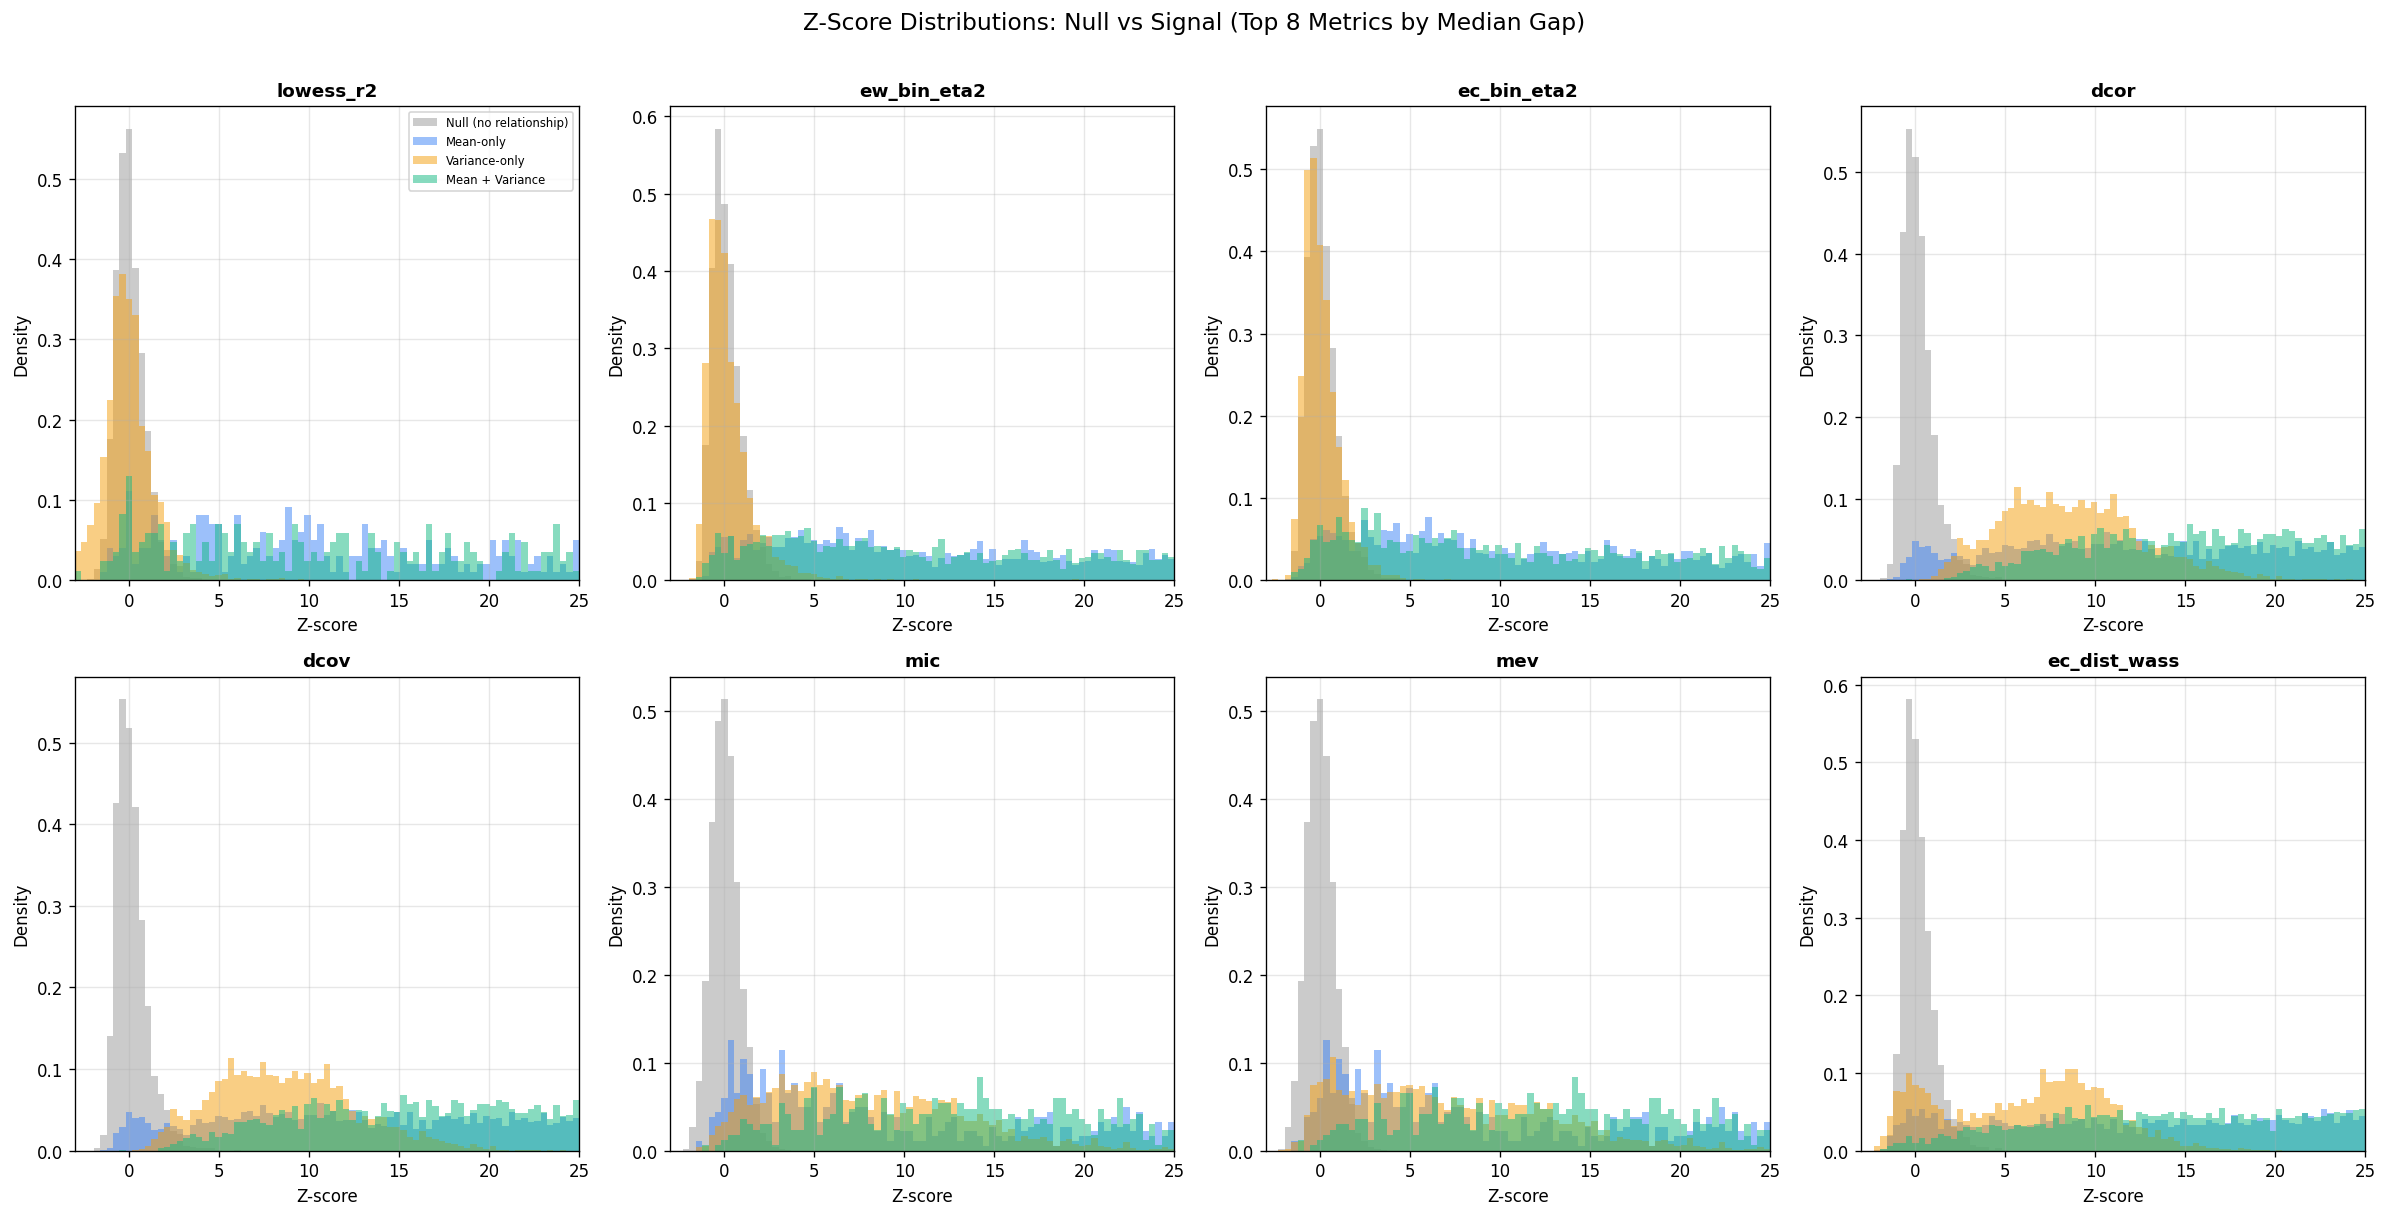

In [5]:
# Top 8 metrics by median signal−null gap
gap_by_zcol = summary.pivot_table(index='z_col', columns='category', values='median')
gap_by_zcol['gap'] = gap_by_zcol[['mean_only', 'variance_only', 'mean+variance']].mean(axis=1) - gap_by_zcol['true_null']
top8 = gap_by_zcol.sort_values('gap', ascending=False).head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
bins = np.linspace(-3, 25, 80)

for i, zc in enumerate(top8):
    ax = axes[i]
    for cat in CAT_ORDER:
        z = df.loc[df['category'] == cat, zc].dropna()
        ax.hist(z, bins=bins, alpha=0.5, density=True, label=CAT_LABELS[cat],
                color=CAT_COLORS[cat], edgecolor='none')
    ax.set_title(METRIC_DISPLAY[zc], fontsize=11, fontweight='bold')
    ax.set_xlabel('Z-score')
    ax.set_ylabel('Density')
    ax.set_xlim(-3, 25)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle('Z-Score Distributions: Null vs Signal (Top 8 Metrics by Median Gap)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig2_zscore_histograms_top8.png', dpi=150, bbox_inches='tight')
plt.show()

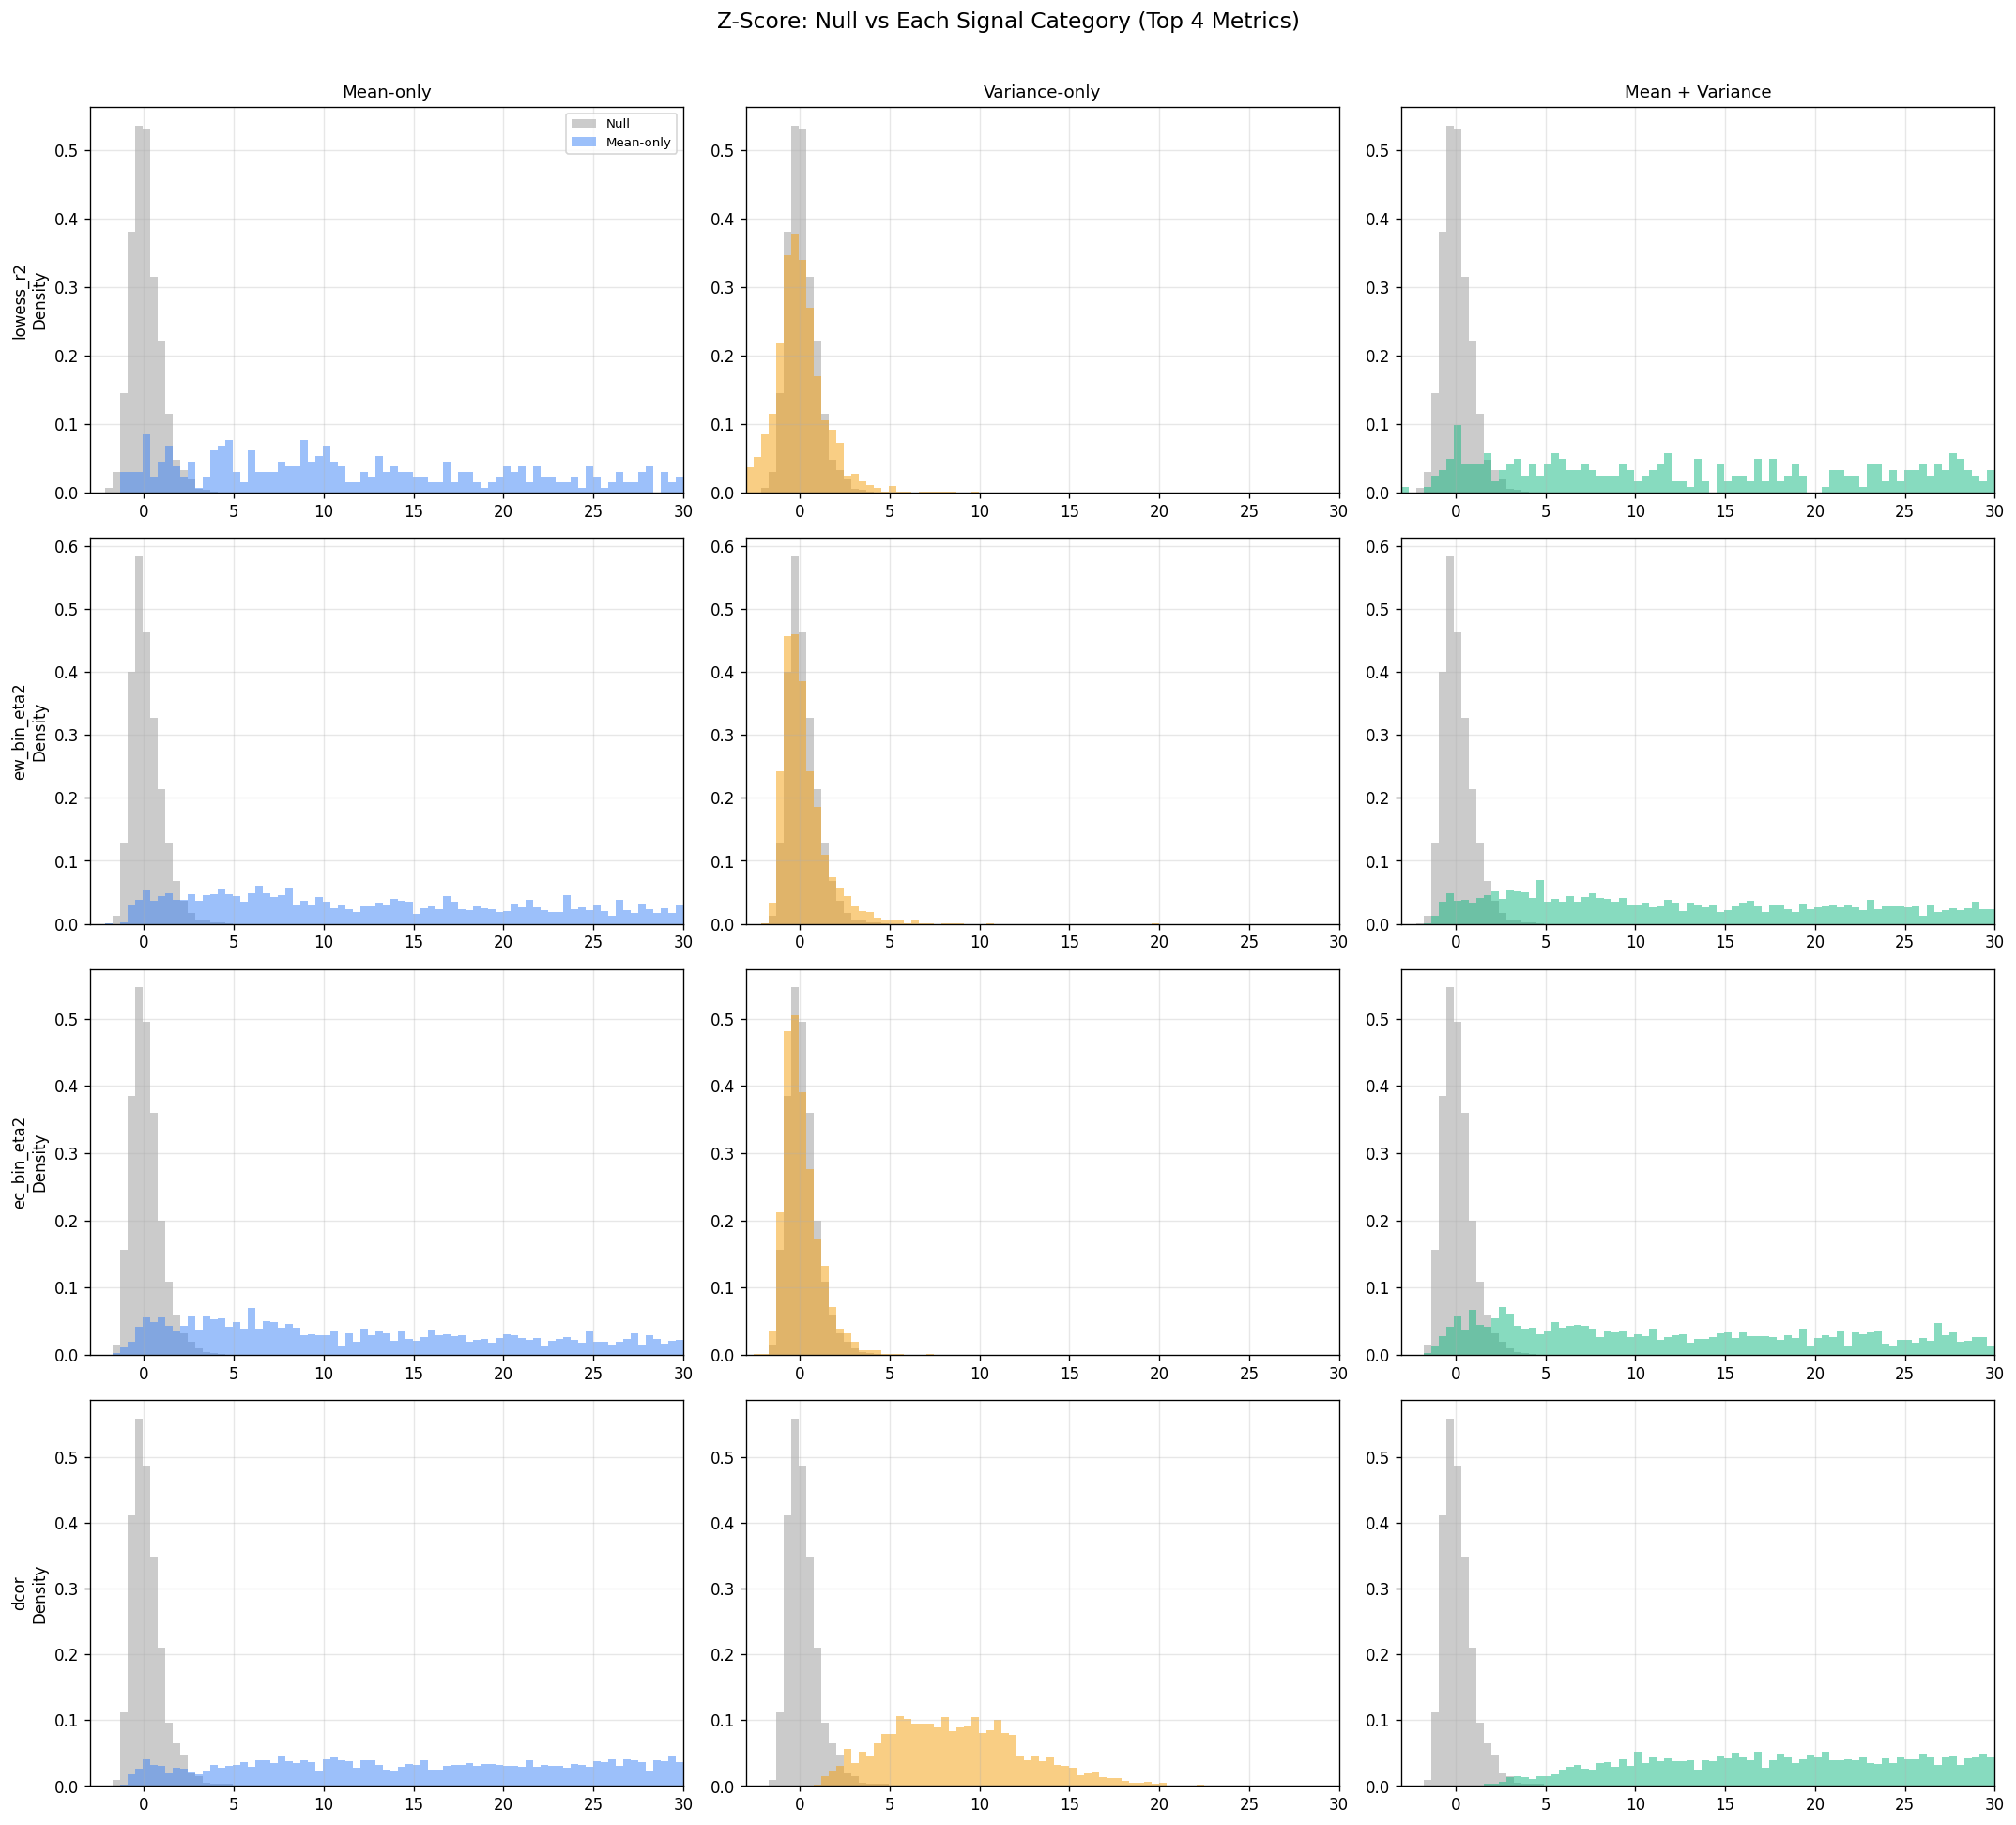

In [6]:
# Same but split by each signal category separately (3 panels per metric, top 4)
top4 = top8[:4]
signal_cats = ['mean_only', 'variance_only', 'mean+variance']

fig, axes = plt.subplots(len(top4), 3, figsize=(18, 4 * len(top4)))
bins = np.linspace(-3, 30, 80)

for row, zc in enumerate(top4):
    for col, cat in enumerate(signal_cats):
        ax = axes[row, col]
        z_null = null_df[zc].dropna()
        z_sig = df.loc[df['category'] == cat, zc].dropna()
        ax.hist(z_null, bins=bins, alpha=0.5, density=True, label='Null',
                color=CAT_COLORS['true_null'], edgecolor='none')
        ax.hist(z_sig, bins=bins, alpha=0.5, density=True, label=CAT_LABELS[cat],
                color=CAT_COLORS[cat], edgecolor='none')
        ax.set_xlim(-3, 30)
        if row == 0:
            ax.set_title(CAT_LABELS[cat], fontsize=11)
        if col == 0:
            ax.set_ylabel(f'{METRIC_DISPLAY[zc]}\nDensity', fontsize=10)
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle('Z-Score: Null vs Each Signal Category (Top 4 Metrics)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig3_zscore_by_category_top4.png', dpi=150, bbox_inches='tight')
plt.show()

## §5 Separation Quality: Cohen's d and AUC

For each metric, quantify how well it separates null from signal:
- **Cohen's d** = (mean_signal − mean_null) / pooled_std — effect size
- **AUC** = probability that a random signal case has higher Z than a random null case

In [7]:
# Use Mann-Whitney U to compute AUC (no sklearn dependency)
signal_df = df[df['category'] != 'true_null']

sep_rows = []
for zc in Z_COLS:
    z_null = null_df[zc].dropna()
    z_sig = signal_df[zc].dropna()
    if len(z_null) == 0 or len(z_sig) == 0:
        continue

    # Cohen's d
    pooled_std = np.sqrt((z_null.std()**2 * (len(z_null) - 1) + z_sig.std()**2 * (len(z_sig) - 1))
                         / (len(z_null) + len(z_sig) - 2))
    d = (z_sig.mean() - z_null.mean()) / pooled_std if pooled_std > 0 else np.nan

    # AUC via Mann-Whitney U: AUC = U / (n1 * n2)
    u_stat, _ = sp_stats.mannwhitneyu(z_sig.values, z_null.values, alternative='greater')
    auc = u_stat / (len(z_sig) * len(z_null))

    # Per-category Cohen's d
    d_by_cat = {}
    for cat in ['mean_only', 'variance_only', 'mean+variance']:
        z_cat = df.loc[df['category'] == cat, zc].dropna()
        if len(z_cat) > 0:
            ps = np.sqrt((z_null.std()**2 * (len(z_null) - 1) + z_cat.std()**2 * (len(z_cat) - 1))
                         / (len(z_null) + len(z_cat) - 2))
            d_by_cat[cat] = (z_cat.mean() - z_null.mean()) / ps if ps > 0 else np.nan

    sep_rows.append({
        'metric': METRIC_DISPLAY[zc],
        'z_col': zc,
        'group': METRIC_GROUPS[zc],
        'cohens_d': d,
        'AUC': auc,
        'd_MO': d_by_cat.get('mean_only', np.nan),
        'd_VO': d_by_cat.get('variance_only', np.nan),
        'd_MV': d_by_cat.get('mean+variance', np.nan),
    })

sep = pd.DataFrame(sep_rows).sort_values('AUC', ascending=False)
print('Separation quality (sorted by AUC):')
print(sep[['metric', 'group', 'cohens_d', 'AUC', 'd_MO', 'd_VO', 'd_MV']]
      .to_string(index=False, float_format='{:.3f}'.format))

sep.to_csv(OUT_DIR / 'separation_quality.csv', index=False, float_format='%.4f')

Separation quality (sorted by AUC):
            metric        group  cohens_d   AUC   d_MO   d_VO   d_MV
              dcov     distance     1.792 0.993  2.379  3.285  2.937
              dcor     distance     1.792 0.993  2.379  3.285  2.937
               mic         mine     1.338 0.973  2.923  2.229  3.659
        ew_dist_ks distribution     1.579 0.963  2.095  1.945  2.550
        ec_dist_ks distribution     1.594 0.962  2.094  1.971  2.621
               mev         mine     1.280 0.949  2.926  1.917  3.649
      ec_dist_wass distribution     1.638 0.948  2.207  1.962  2.595
      ew_dist_wass distribution     1.593 0.942  2.181  1.872  2.489
               mas         mine     1.266 0.916  0.923  2.293  1.377
        ec_bin_amp          bin     0.277 0.876  2.684  0.110  0.276
       ew_bin_eta2          bin     1.261 0.871  2.084  0.104  2.128
        |spearman|  correlation     1.328 0.868  2.144  0.516  2.246
       ec_bin_eta2          bin     1.262 0.867  2.095 -0.013  2.13

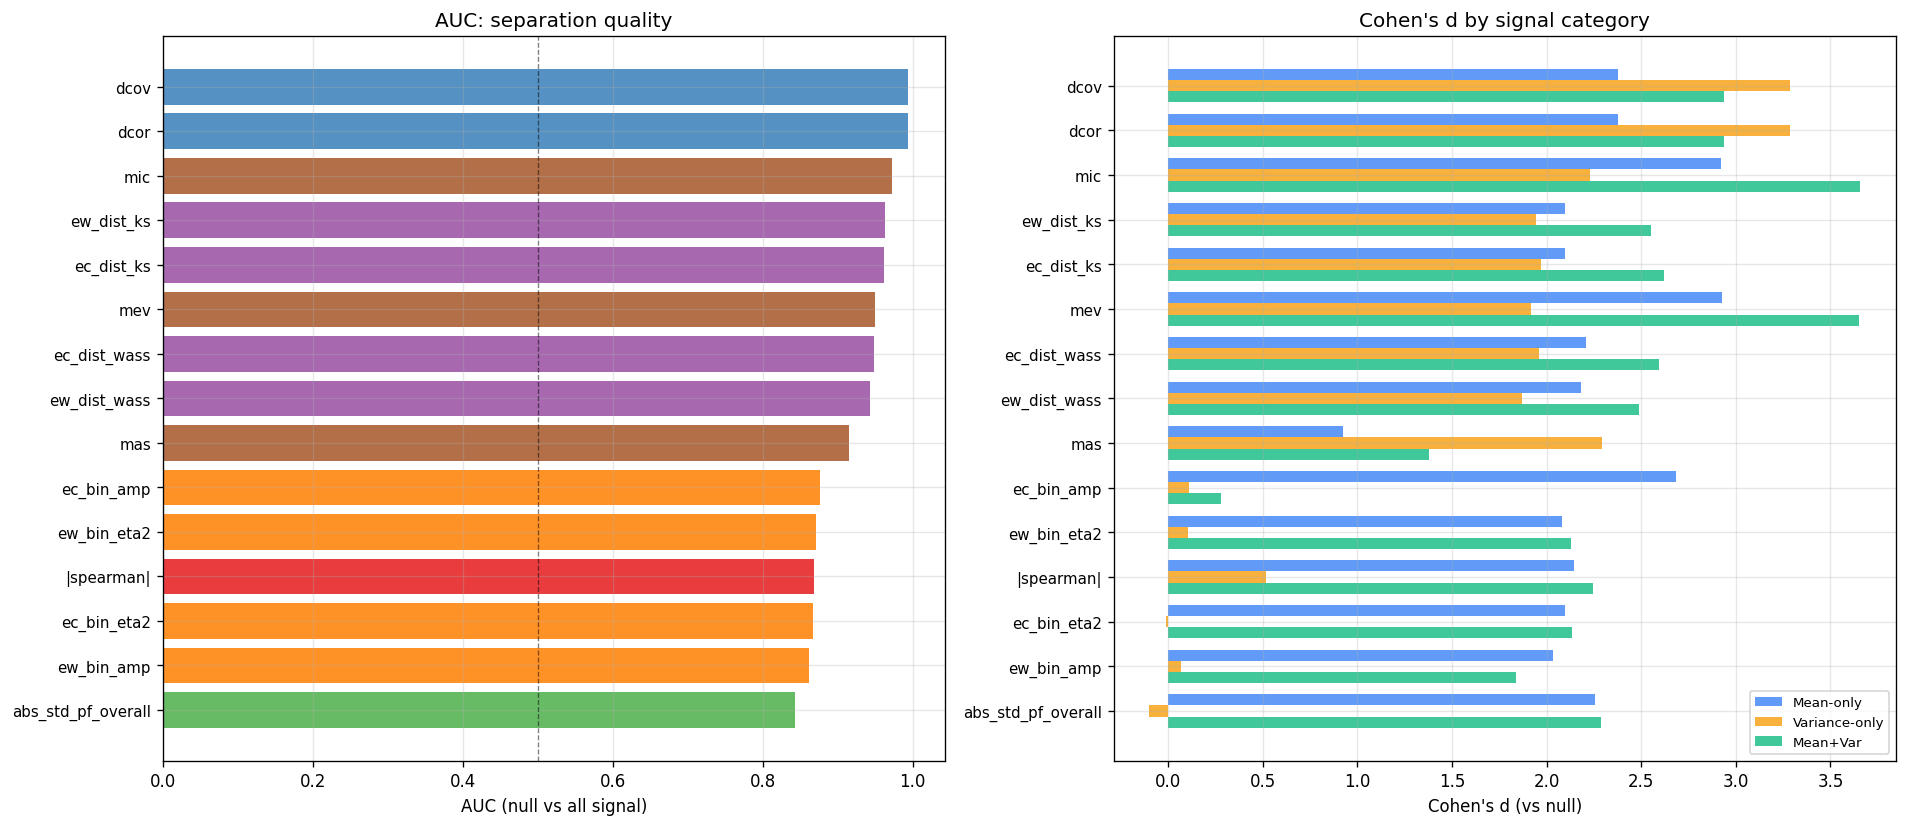

In [8]:
# Bar chart: AUC and Cohen's d for top 15 metrics
top15 = sep.head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = [GROUP_COLORS.get(g, '#999') for g in top15['group']]

ax = axes[0]
ax.barh(range(len(top15)), top15['AUC'], color=colors, alpha=0.85)
ax.axvline(0.5, color='black', ls='--', lw=0.8, alpha=0.5)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['metric'], fontsize=9)
ax.set_xlabel('AUC (null vs all signal)')
ax.set_title('AUC: separation quality')
ax.invert_yaxis()

ax = axes[1]
width = 0.25
y = np.arange(len(top15))
ax.barh(y - width, top15['d_MO'], width, label='Mean-only', color=CAT_COLORS['mean_only'], alpha=0.8)
ax.barh(y, top15['d_VO'], width, label='Variance-only', color=CAT_COLORS['variance_only'], alpha=0.8)
ax.barh(y + width, top15['d_MV'], width, label='Mean+Var', color=CAT_COLORS['mean+variance'], alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(top15['metric'], fontsize=9)
ax.set_xlabel("Cohen's d (vs null)")
ax.set_title("Cohen's d by signal category")
ax.legend(fontsize=8)
ax.invert_yaxis()

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig4_separation_auc_cohensd.png', dpi=150, bbox_inches='tight')
plt.show()

## §6 Z-Score Heatmap: Mean Z by Metric × Category

A single heatmap showing which metrics respond to which types of relationships.

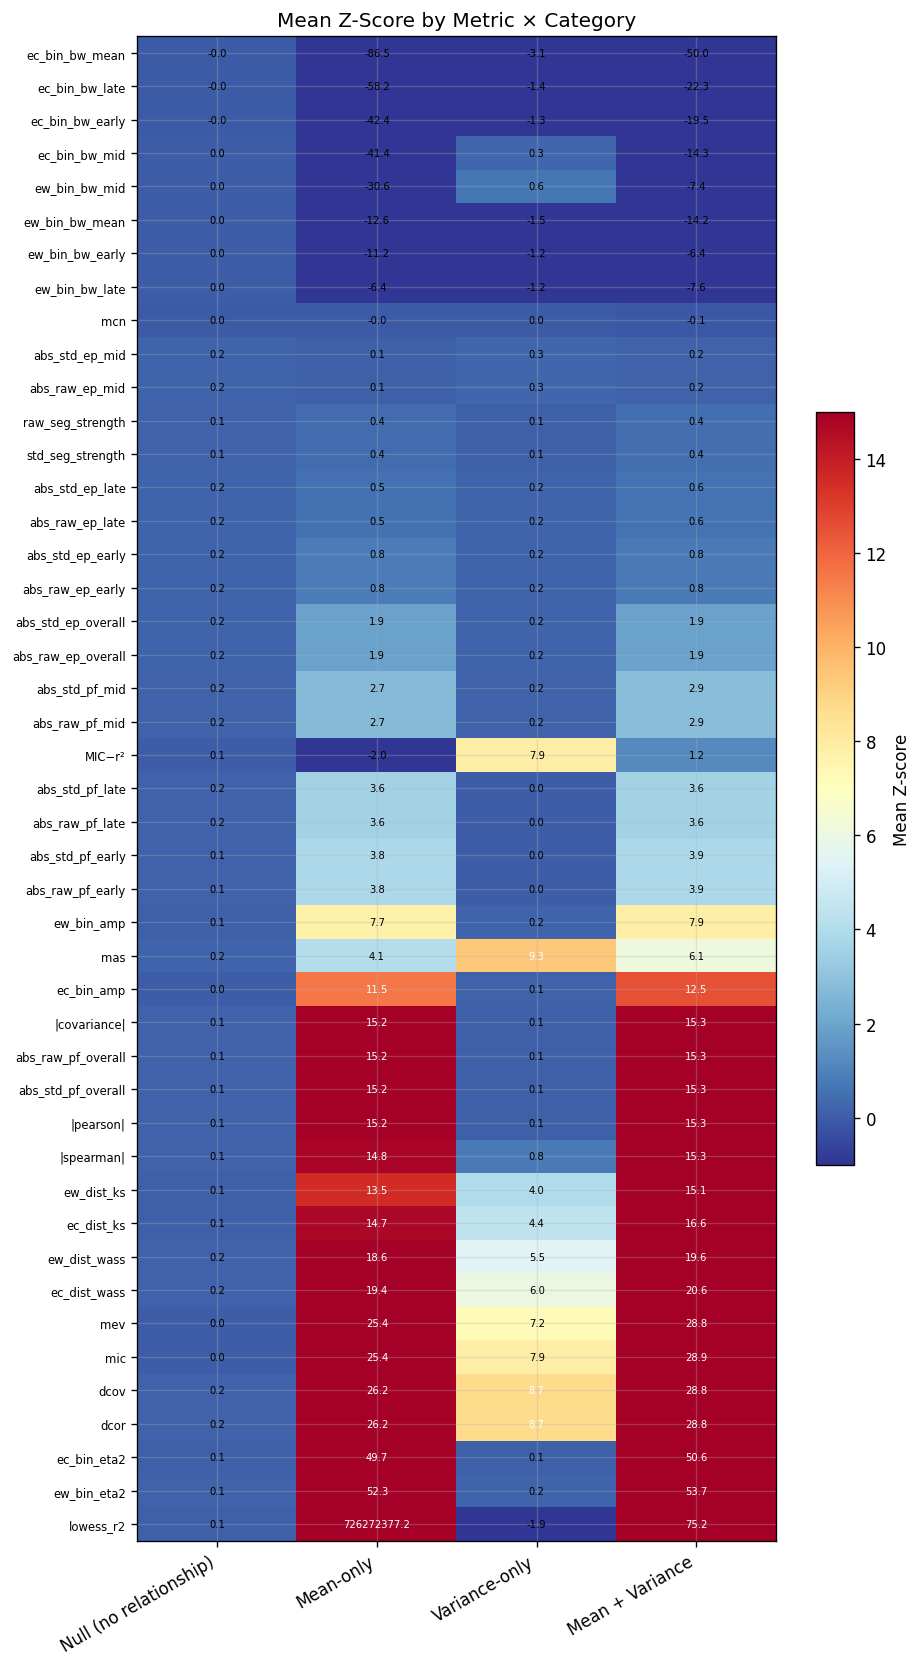

In [9]:
# Build heatmap data: mean Z per metric × category
heat_data = summary.pivot_table(index='z_col', columns='category', values='mean')
heat_data = heat_data[CAT_ORDER]
heat_data.index = [METRIC_DISPLAY[zc] for zc in heat_data.index]

# Sort by overall signal strength
heat_data['signal_avg'] = heat_data[['mean_only', 'variance_only', 'mean+variance']].mean(axis=1)
heat_data = heat_data.sort_values('signal_avg', ascending=True)
heat_data = heat_data.drop(columns='signal_avg')

fig, ax = plt.subplots(figsize=(8, 14))
im = ax.imshow(heat_data.values, aspect='auto', cmap='RdYlBu_r', vmin=-1, vmax=15)

ax.set_xticks(range(len(CAT_ORDER)))
ax.set_xticklabels([CAT_LABELS[c] for c in CAT_ORDER], fontsize=10, rotation=30, ha='right')
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=7)

# Annotate cells
for i in range(len(heat_data)):
    for j in range(len(CAT_ORDER)):
        val = heat_data.iloc[i, j]
        if not np.isnan(val):
            color = 'white' if val > 8 else 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=6, color=color)

ax.set_title('Mean Z-Score by Metric × Category')
fig.colorbar(im, ax=ax, shrink=0.5, label='Mean Z-score')

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig5_zscore_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## §7 Z-Score by SNR

How does Z-score grow with signal strength? For the top metrics, plot mean Z vs SNR for each signal category. This shows the "dose-response" curve of each metric.

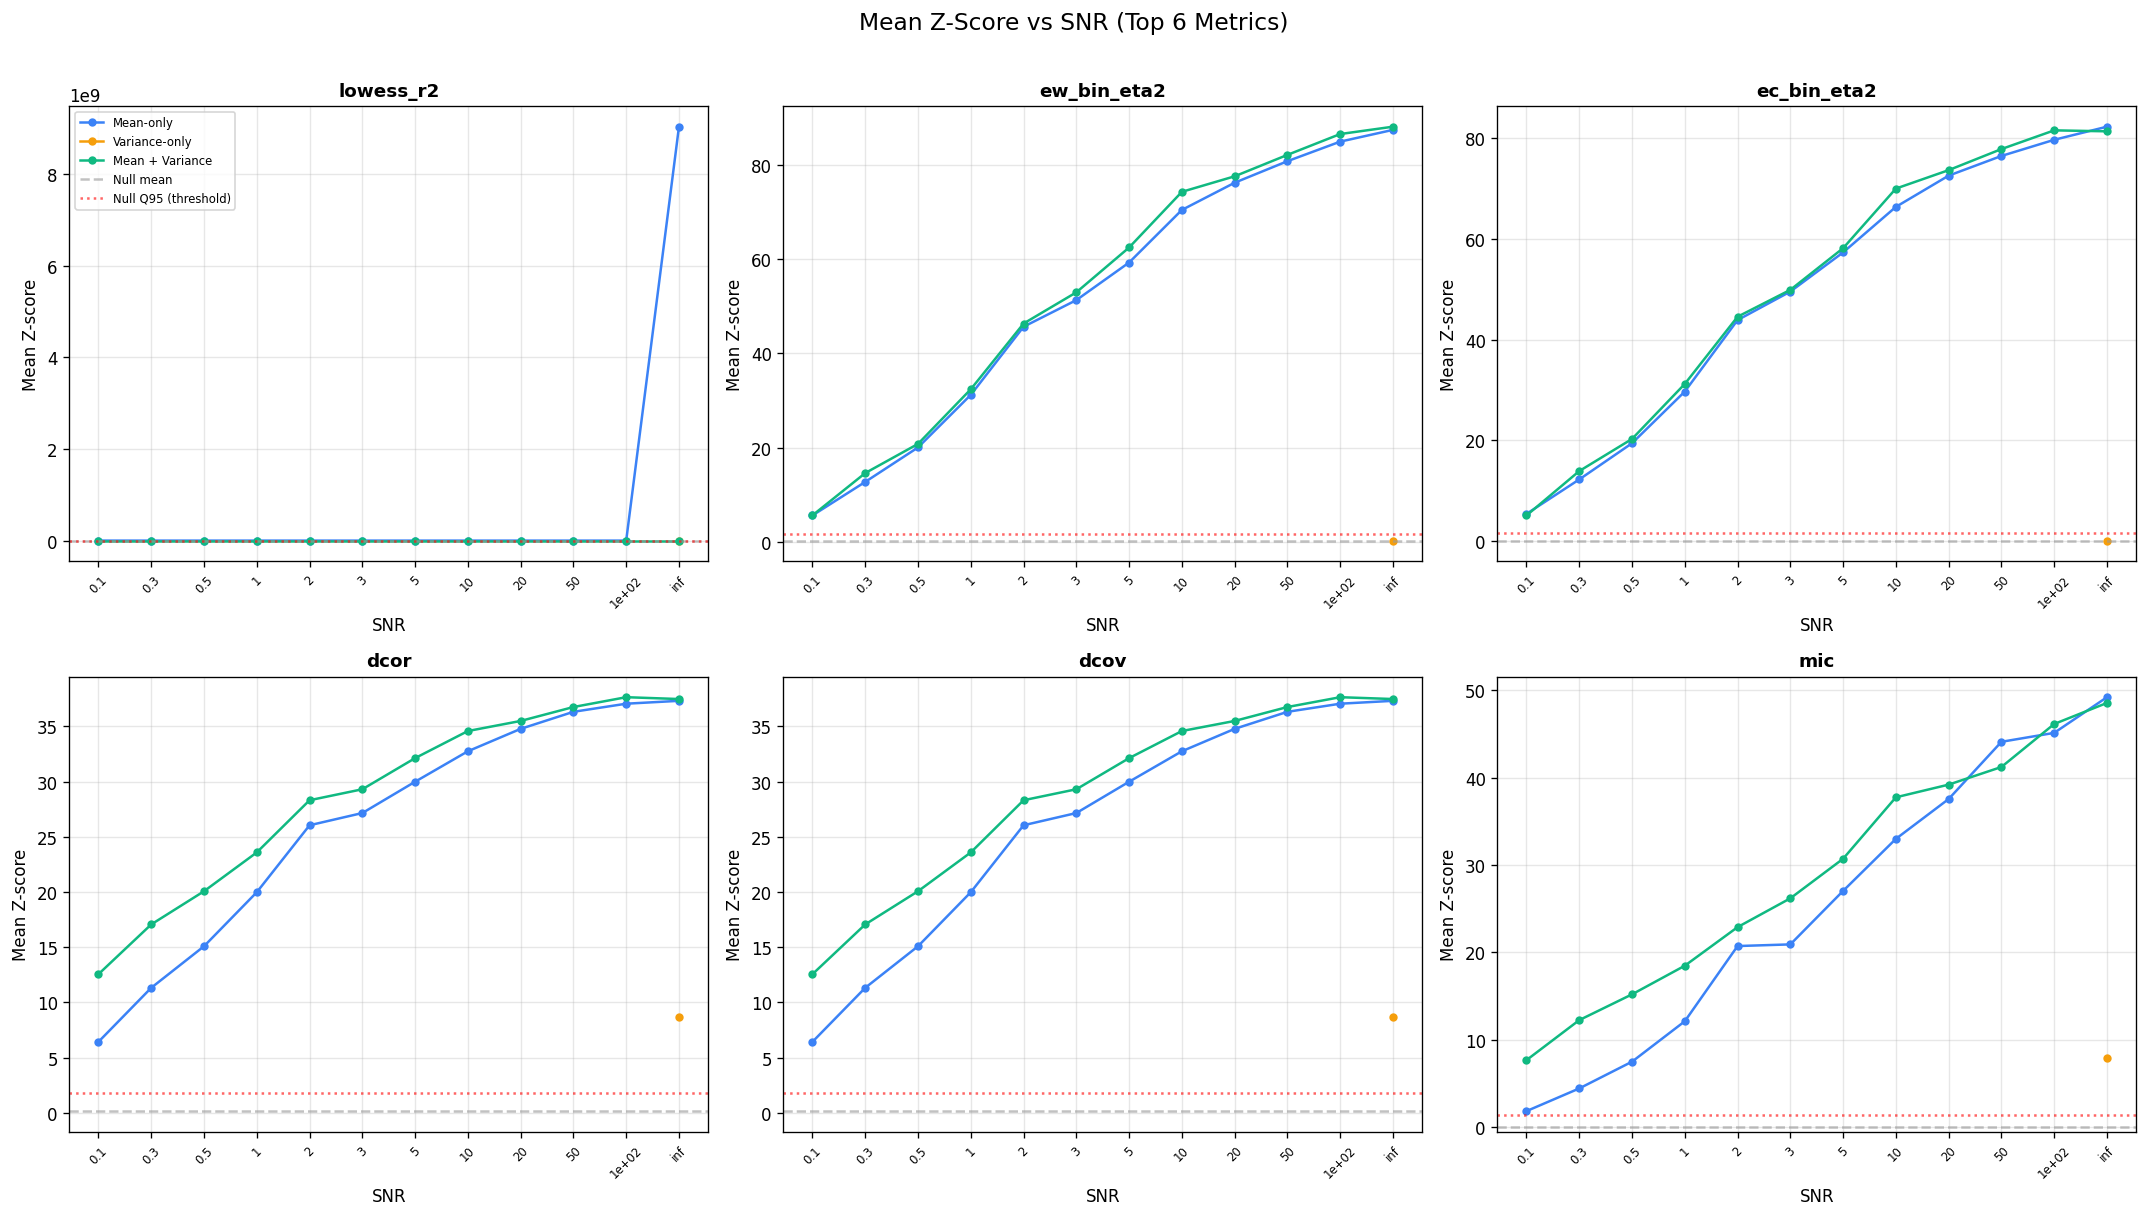

In [10]:
snr_levels = sorted(df['snr'].dropna().unique())
top6 = gap_by_zcol.sort_values('gap', ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, zc in enumerate(top6):
    ax = axes[i]
    for cat in ['mean_only', 'variance_only', 'mean+variance']:
        means = []
        for snr in snr_levels:
            z = df.loc[(df['category'] == cat) & (df['snr'] == snr), zc].dropna()
            means.append(z.mean() if len(z) > 0 else np.nan)
        ax.plot(range(len(snr_levels)), means, '-o', label=CAT_LABELS[cat],
                color=CAT_COLORS[cat], markersize=4, lw=1.5)

    # Null reference band
    z_null_mean = null_df[zc].dropna().mean()
    z_null_q95 = np.nanpercentile(null_df[zc].dropna(), 95)
    ax.axhline(z_null_mean, color=CAT_COLORS['true_null'], ls='--', alpha=0.6, label='Null mean')
    ax.axhline(z_null_q95, color='red', ls=':', alpha=0.6, label='Null Q95 (threshold)')

    ax.set_xticks(range(len(snr_levels)))
    ax.set_xticklabels([f'{s:.2g}' for s in snr_levels], rotation=45, fontsize=7)
    ax.set_xlabel('SNR')
    ax.set_ylabel('Mean Z-score')
    ax.set_title(METRIC_DISPLAY[zc], fontsize=11, fontweight='bold')
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Mean Z-Score vs SNR (Top 6 Metrics)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig6_zscore_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Low-SNR zoom: mean Z at the 4 lowest SNR levels
low_snr = snr_levels[:4]
signal_cats = ['mean_only', 'variance_only', 'mean+variance']

# Compute for all metrics
low_snr_rows = []
for zc in Z_COLS:
    for cat in signal_cats:
        for snr in low_snr:
            z = df.loc[(df['category'] == cat) & (df['snr'] == snr), zc].dropna()
            low_snr_rows.append({
                'metric': METRIC_DISPLAY[zc],
                'z_col': zc,
                'group': METRIC_GROUPS[zc],
                'category': cat,
                'snr': snr,
                'mean_z': z.mean() if len(z) > 0 else np.nan,
                'n': len(z),
            })

low_snr_df = pd.DataFrame(low_snr_rows)

# Average across categories and low SNR levels → "low-SNR sensitivity"
low_snr_avg = low_snr_df.groupby(['metric', 'z_col', 'group'])['mean_z'].mean().reset_index()
low_snr_avg = low_snr_avg.sort_values('mean_z', ascending=False)

print(f'Mean Z at low SNR ({low_snr}) — averaged across MO/VO/MV:')
print(low_snr_avg[['metric', 'group', 'mean_z']].head(20).to_string(index=False, float_format='{:.3f}'.format))

Mean Z at low SNR ([0.1, 0.3, 0.5, 1.0]) — averaged across MO/VO/MV:
            metric        group  mean_z
         lowess_r2    nonlinear  20.945
       ew_bin_eta2          bin  17.870
       ec_bin_eta2          bin  17.156
              dcov     distance  15.769
              dcor     distance  15.769
      ec_dist_wass distribution  11.819
      ew_dist_wass distribution  11.102
               mic         mine   9.931
               mev         mine   9.899
        ec_dist_ks distribution   8.929
        |spearman|  correlation   8.430
        ew_dist_ks distribution   8.385
abs_std_pf_overall        slope   8.337
abs_raw_pf_overall        slope   8.337
      |covariance|  correlation   8.337
         |pearson|  correlation   8.337
        ec_bin_amp          bin   5.860
               mas         mine   3.895
        ew_bin_amp          bin   3.843
  abs_raw_pf_early        slope   1.870


## §8 Metric Correlation Matrix

Z-score correlations across all cases. High correlation means metrics are redundant — they detect the same signals.

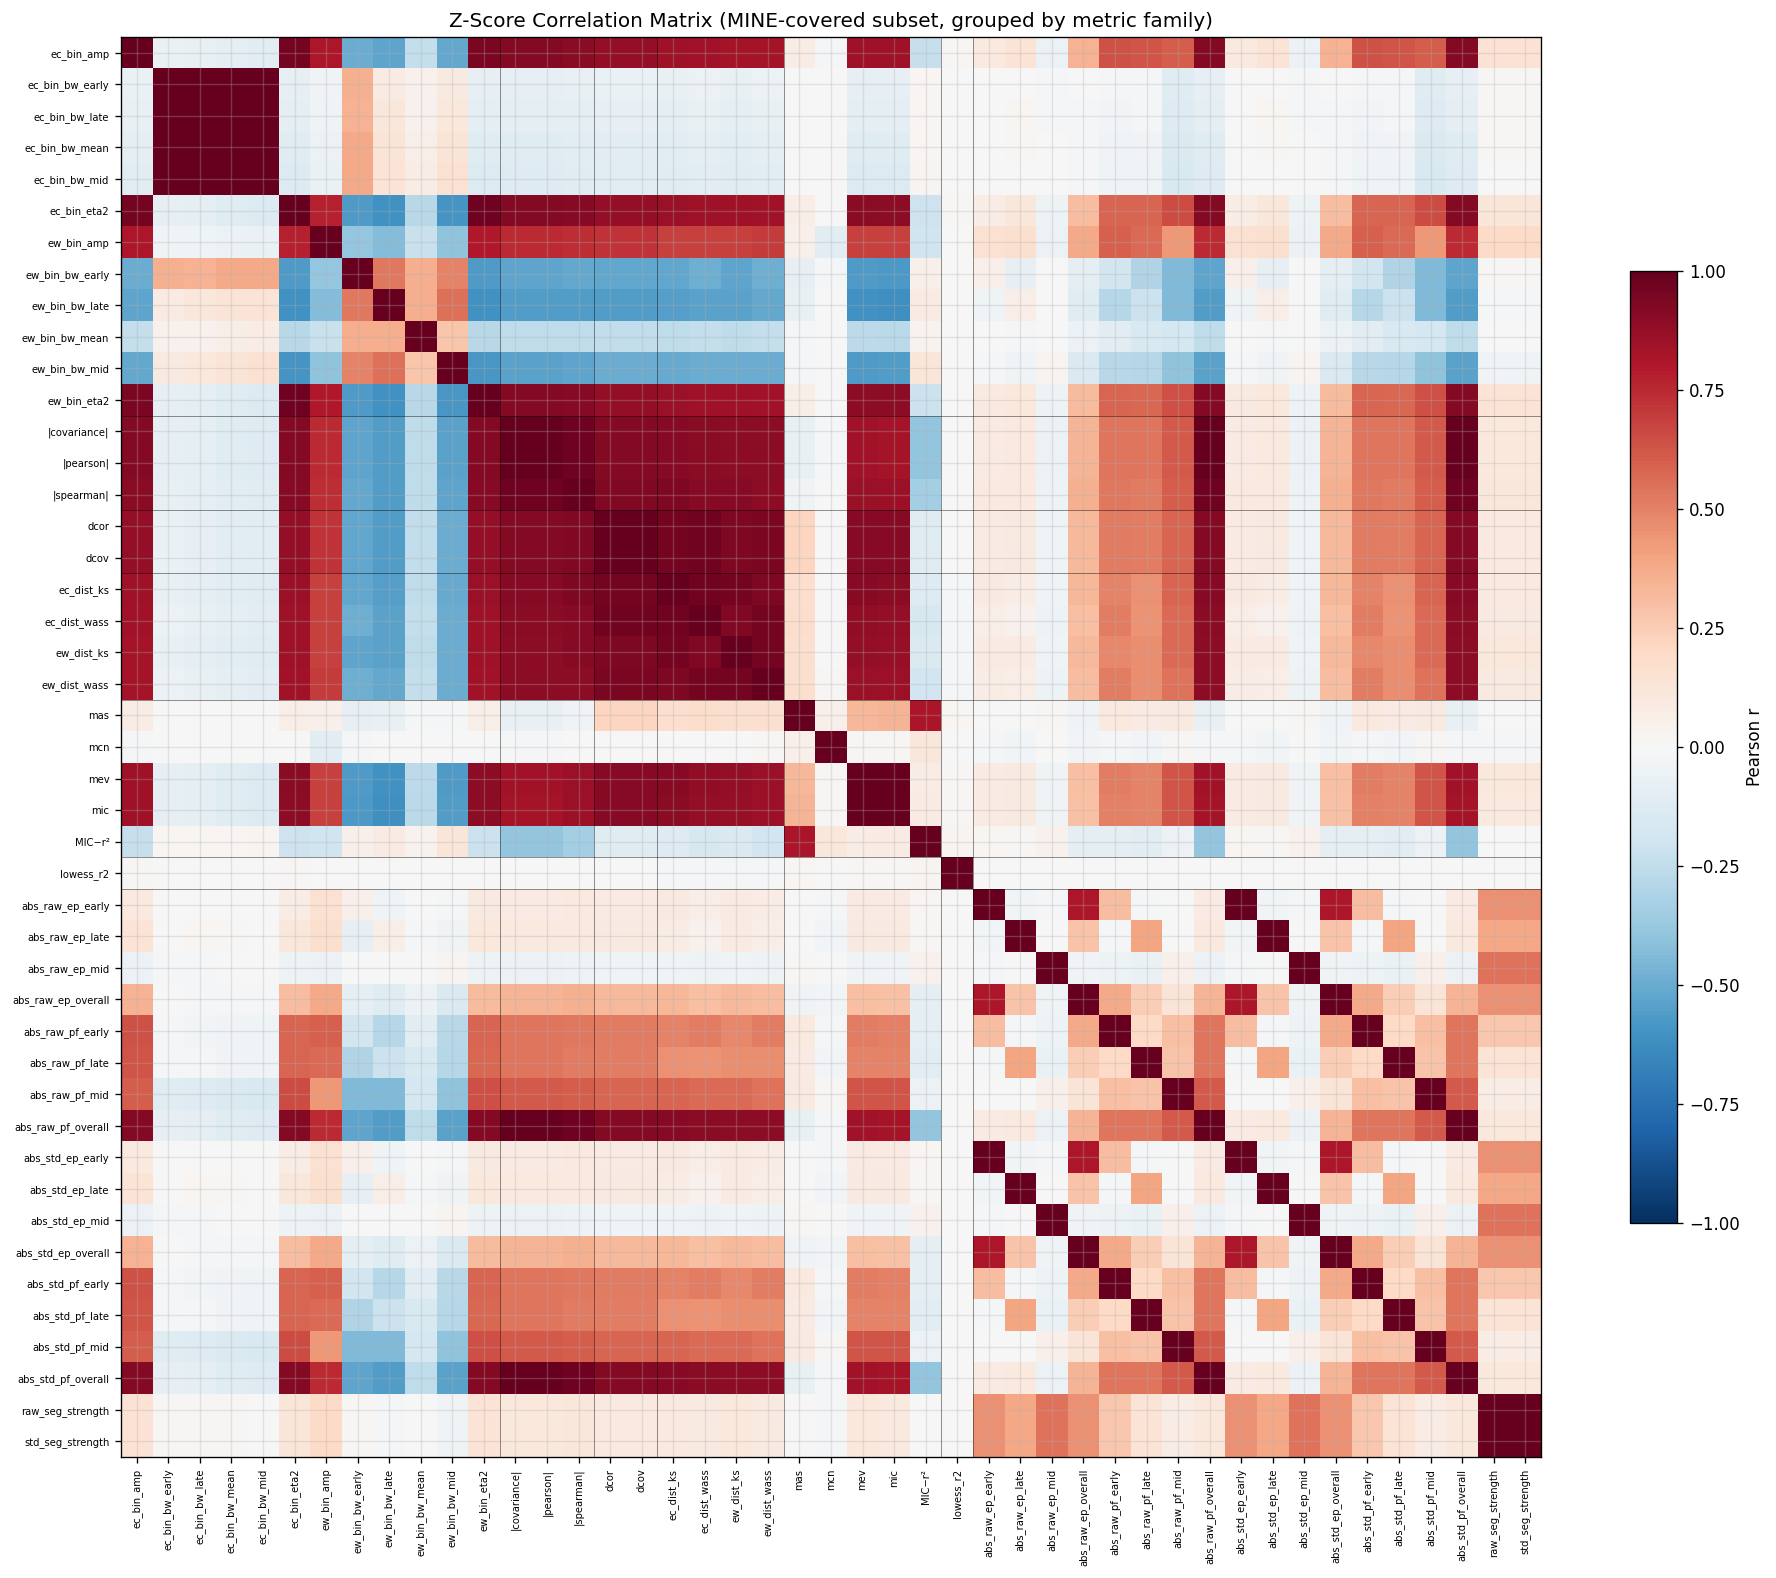


Highly correlated pairs (|r| > 0.9): 85
  abs_raw_ep_overall        × abs_std_ep_overall         r=1.000
  |covariance|              × abs_std_pf_overall         r=1.000
  |pearson|                 × abs_raw_pf_overall         r=1.000
  abs_raw_ep_late           × abs_std_ep_late            r=1.000
  abs_raw_ep_mid            × abs_std_ep_mid             r=1.000
  abs_raw_pf_early          × abs_std_pf_early           r=1.000
  abs_raw_pf_mid            × abs_std_pf_mid             r=1.000
  abs_raw_pf_overall        × abs_std_pf_overall         r=1.000
  raw_seg_strength          × std_seg_strength           r=1.000
  abs_raw_pf_late           × abs_std_pf_late            r=1.000
  |covariance|              × abs_raw_pf_overall         r=1.000
  |pearson|                 × abs_std_pf_overall         r=1.000
  abs_raw_ep_early          × abs_std_ep_early           r=1.000
  dcor                      × dcov                       r=1.000
  |covariance|              × |pearson|          

In [12]:
# Correlation matrix of Z-scores
# Use only cases with full coverage (MINE subset)
mine_z = [c for c in Z_COLS if c in ('z_mic', 'z_mas', 'z_mev', 'z_mcn')]
mine_mask = df[mine_z].notna().all(axis=1)
df_full = df[mine_mask]

corr = df_full[Z_COLS].corr()

# Reorder by group for visual clustering
order = sorted(Z_COLS, key=lambda c: (METRIC_GROUPS[c], c))
corr = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')

labels = [METRIC_DISPLAY[c] for c in order]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=6, rotation=90)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=6)

# Group boundaries
groups_in_order = [METRIC_GROUPS[c] for c in order]
boundaries = []
prev = groups_in_order[0]
for i, g in enumerate(groups_in_order):
    if g != prev:
        boundaries.append(i - 0.5)
        prev = g
for b in boundaries:
    ax.axhline(b, color='black', lw=0.5, alpha=0.5)
    ax.axvline(b, color='black', lw=0.5, alpha=0.5)

ax.set_title('Z-Score Correlation Matrix (MINE-covered subset, grouped by metric family)')
fig.colorbar(im, ax=ax, shrink=0.6, label='Pearson r')

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig7_zscore_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print highly correlated pairs (|r| > 0.9, excluding self)
high_corr = []
for i in range(len(order)):
    for j in range(i + 1, len(order)):
        r = corr.iloc[i, j]
        if abs(r) > 0.9:
            high_corr.append((METRIC_DISPLAY[order[i]], METRIC_DISPLAY[order[j]], r))

high_corr.sort(key=lambda x: -abs(x[2]))
print(f'\nHighly correlated pairs (|r| > 0.9): {len(high_corr)}')
for m1, m2, r in high_corr[:20]:
    print(f'  {m1:25s} × {m2:25s}  r={r:.3f}')

## §9 Box Plot: Z-Score by Category (Top Metrics)

Box plots give a quick visual of the Z-score range and overlap between null and signal categories.

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_51323/3039734570.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cat, labels=[c.replace('_', '\n') for c in CAT_ORDER],
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_51323/3039734570.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cat, labels=[c.replace('_', '\n') for c in CAT_ORDER],
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_51323/3039734570.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cat, labels=[c.replace('_', '\n') for c in CAT_ORDER],
/var

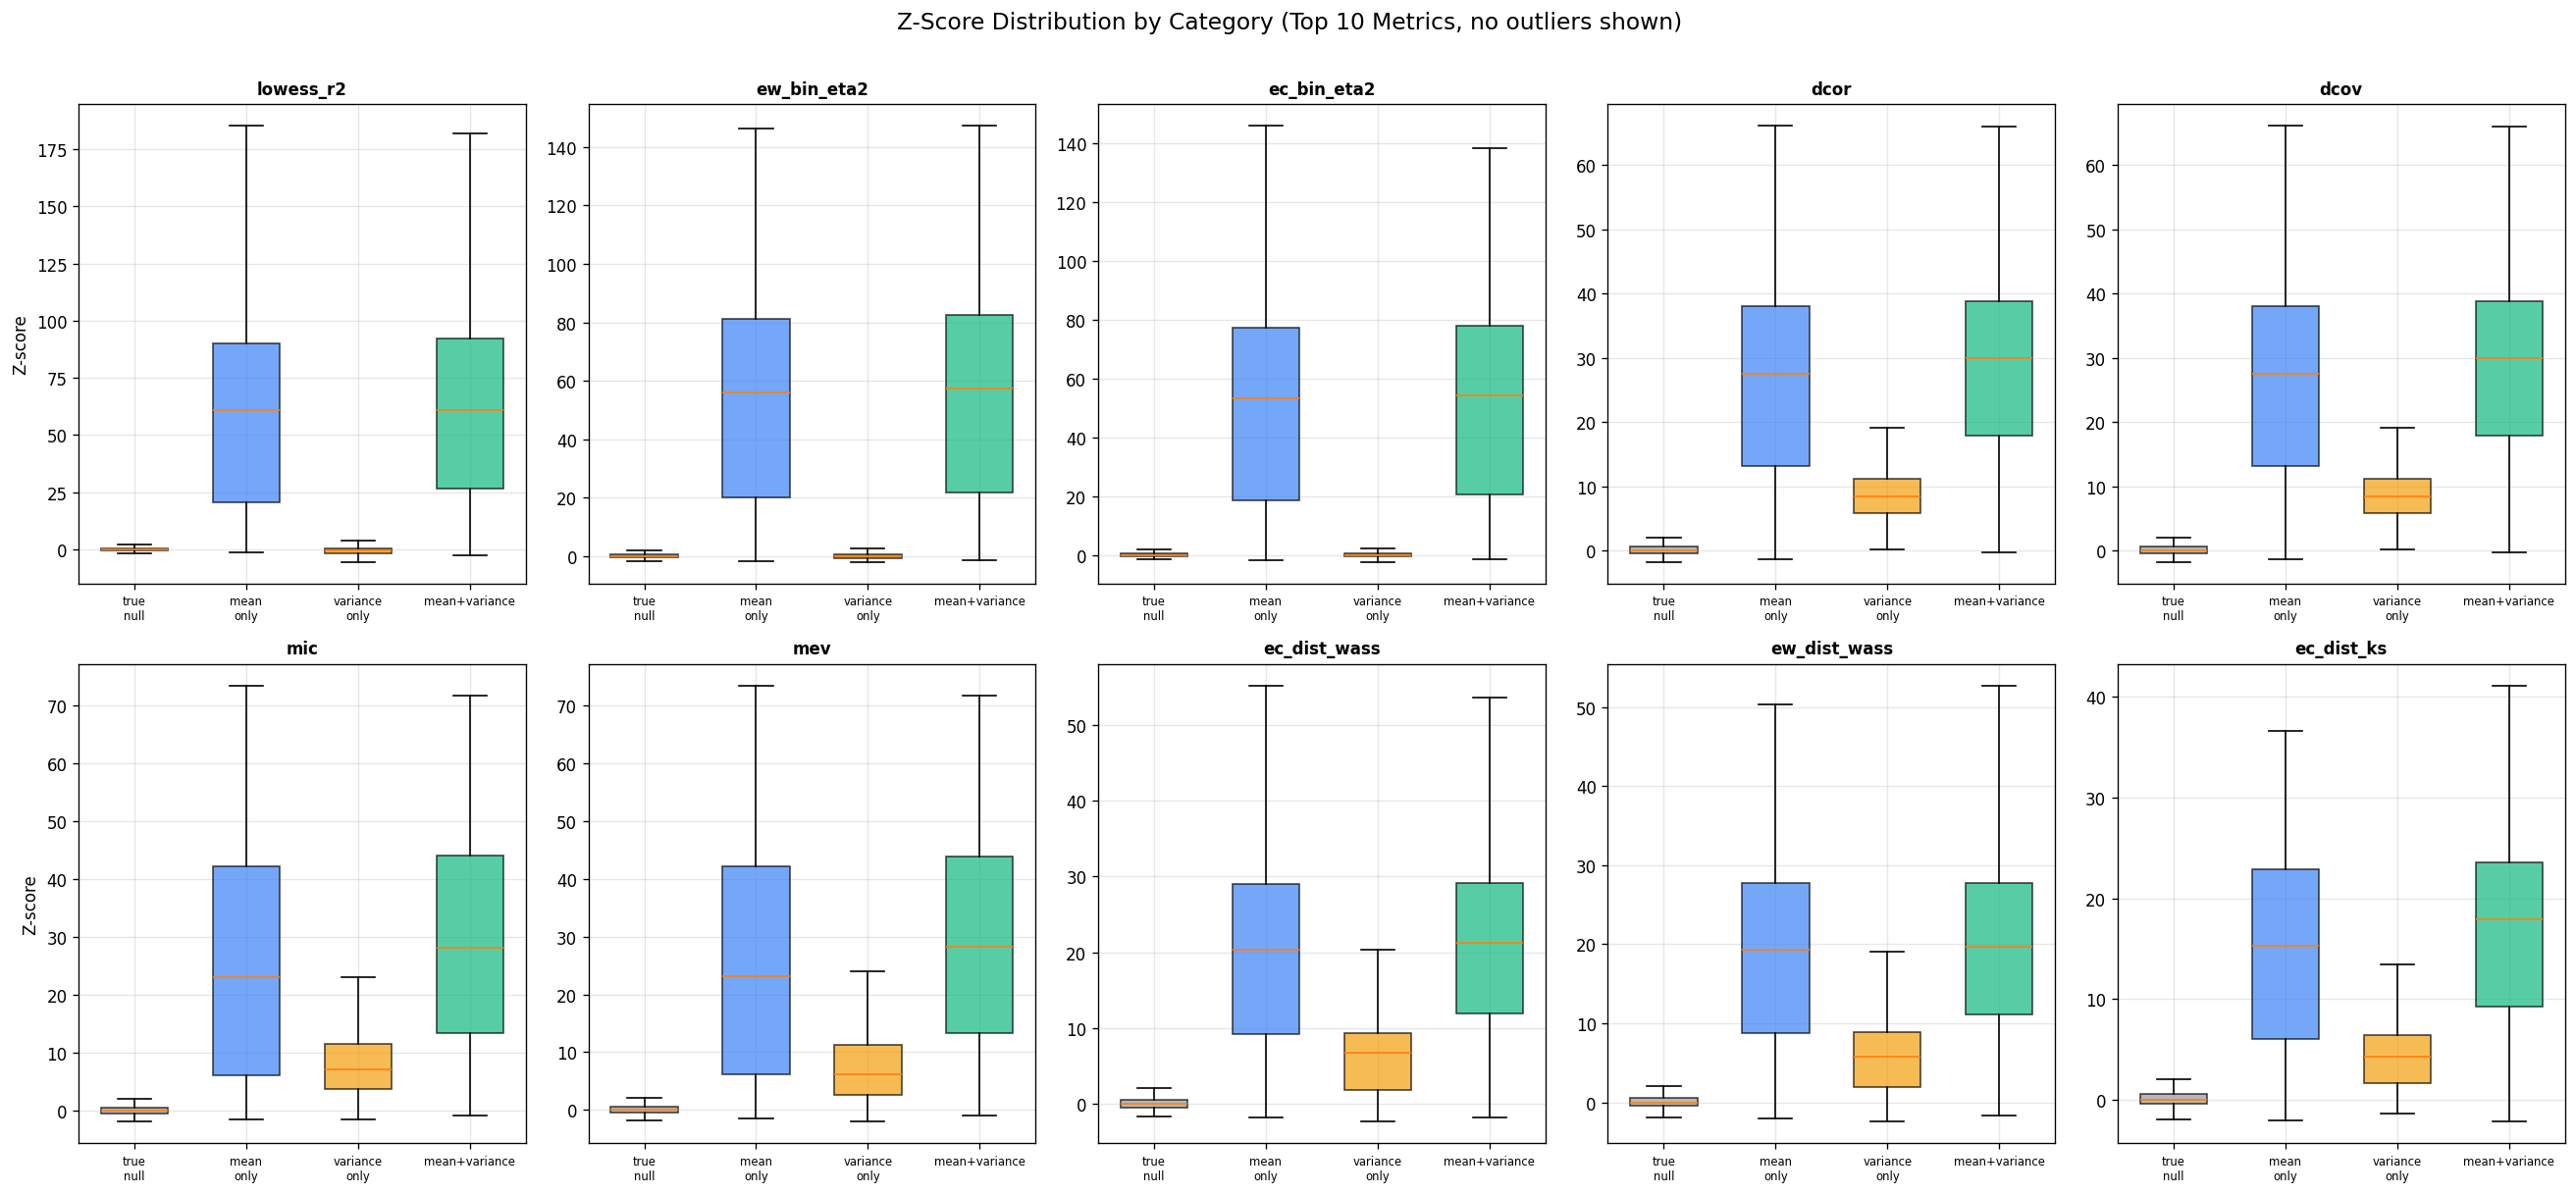

In [13]:
top10_zcols = gap_by_zcol.sort_values('gap', ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, zc in enumerate(top10_zcols):
    ax = axes[i]
    data_by_cat = [df.loc[df['category'] == cat, zc].dropna().values for cat in CAT_ORDER]
    bp = ax.boxplot(data_by_cat, labels=[c.replace('_', '\n') for c in CAT_ORDER],
                    patch_artist=True, showfliers=False, widths=0.6)
    for patch, cat in zip(bp['boxes'], CAT_ORDER):
        patch.set_facecolor(CAT_COLORS[cat])
        patch.set_alpha(0.7)
    ax.set_title(METRIC_DISPLAY[zc], fontsize=10, fontweight='bold')
    ax.set_ylabel('Z-score' if i % 5 == 0 else '')
    ax.tick_params(axis='x', labelsize=7)

fig.suptitle('Z-Score Distribution by Category (Top 10 Metrics, no outliers shown)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig8_boxplots_top10.png', dpi=150, bbox_inches='tight')
plt.show()

## §10 Summary

Key outputs saved to `output/S3.7/`:
- `null_calibration.csv` — null Z-score summary per metric
- `summary_by_category.csv` — mean/median/Q95 by metric × category
- `separation_quality.csv` — AUC and Cohen's d per metric
- Figures 1–8

In [14]:
print('=' * 70)
print('B_S3.7 Z-Score Distribution Analysis — Summary')
print('=' * 70)

print(f'\nDataset: {len(df):,} cases, {len(Z_COLS)} Z-score metrics')
print(f'MINE-covered subset: {mine_mask.sum():,} cases')

print('\n── Top 5 metrics by AUC (null vs all signal) ──')
for _, row in sep.head(5).iterrows():
    print(f'  {row["metric"]:20s}  AUC={row["AUC"]:.3f}  d={row["cohens_d"]:.2f}  (MO={row["d_MO"]:.2f}, VO={row["d_VO"]:.2f}, MV={row["d_MV"]:.2f})')

print('\n── Null calibration issues (|median| > 0.1 or IQR deviates from 1 by > 0.3) ──')
issues = calib[(calib['|median|'] > 0.1) | ((calib['IQR'] - 1).abs() > 0.3)]
if len(issues):
    for _, row in issues.iterrows():
        print(f'  {row["metric"]:20s}  median={row["median"]:.3f}  IQR={row["IQR"]:.3f}')
else:
    print('  None — all metrics well-calibrated under null')

print(f'\n── Highly correlated metric pairs (|r| > 0.95) ──')
very_high = [(m1, m2, r) for m1, m2, r in high_corr if abs(r) > 0.95]
for m1, m2, r in very_high[:10]:
    print(f'  {m1:25s} × {m2:25s}  r={r:.3f}')

print(f'\nSaved to {OUT_DIR}')

B_S3.7 Z-Score Distribution Analysis — Summary

Dataset: 17,008 cases, 45 Z-score metrics
MINE-covered subset: 9,008 cases

── Top 5 metrics by AUC (null vs all signal) ──
  dcov                  AUC=0.993  d=1.79  (MO=2.38, VO=3.28, MV=2.94)
  dcor                  AUC=0.993  d=1.79  (MO=2.38, VO=3.28, MV=2.94)
  mic                   AUC=0.973  d=1.34  (MO=2.92, VO=2.23, MV=3.66)
  ew_dist_ks            AUC=0.963  d=1.58  (MO=2.10, VO=1.95, MV=2.55)
  ec_dist_ks            AUC=0.962  d=1.59  (MO=2.09, VO=1.97, MV=2.62)

── Null calibration issues (|median| > 0.1 or IQR deviates from 1 by > 0.3) ──
  mcn                   median=0.000  IQR=0.000

── Highly correlated metric pairs (|r| > 0.95) ──
  abs_raw_ep_overall        × abs_std_ep_overall         r=1.000
  |covariance|              × abs_std_pf_overall         r=1.000
  |pearson|                 × abs_raw_pf_overall         r=1.000
  abs_raw_ep_late           × abs_std_ep_late            r=1.000
  abs_raw_ep_mid            × abs_